<a href="https://colab.research.google.com/github/Maryam-Skaik/airline-customer-segmentation-and-satisfaction-prediction/blob/main/notebook/Airline_Customer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Customer Analysis — Clustering & Satisfaction Prediction

## Imports

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

## Custom Function

In [ ]:
def plot_history(history, figsize=(8,6)):

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(loss))

    plt.figure(figsize=figsize)

    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')

    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

## Load Dataset

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/Practice/Data/flight_df - flight_df.csv'
df = pd.read_csv(fpath)
df.head()

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Loyal Customer,Business Travel,satisfied
0,26,3,2062,2,3,3,3,2,2,2,2,3,3,3,3,3,2,0,0,0,1,1,0
1,52,3,680,5,5,5,5,3,4,4,4,4,4,4,4,4,4,18,2,0,1,1,1
2,28,1,188,3,5,3,4,3,3,3,3,3,3,4,4,5,3,0,0,1,1,0,0
3,54,3,453,3,5,5,5,3,4,4,3,3,3,3,4,3,1,91,80,0,1,1,0
4,40,1,775,4,3,3,3,4,4,4,4,1,1,3,3,3,4,0,0,1,1,1,0


- The dataset represents airline customer information along with their satisfaction level. From the first look, each row corresponds to a single customer and includes demographic details, travel characteristics, service ratings, and delay information.

- A large part of the dataset is focused on service quality ratings. These include `Inflight wifi service`, `Departure/Arrival time convenient`, `Ease of Online booking`, `Gate location`, `Food and drink`, `Online boarding`, `Seat comfort`, `Inflight entertainment`, `On-board service`, `Leg room service`, `Baggage handling`, `Checkin service`, `Inflight service`, and `Cleanliness`. These features appear to be rated on a numerical scale, likely from low to high satisfaction.

- There are also operational delay features: `Departure Delay in Minutes` and `Arrival Delay in Minutes`, which measure travel disruptions.

- Some binary encoded features are included such as `Gender_Male`, `Loyal Customer`, and `Business Travel`, which describe customer type and travel purpose.

- Finally, the target variable `is satisfied`, which likely indicates whether the customer is satisfied (1) or not satisfied (0).

- Overall, the dataset is structured for a classification problem where satisfaction is influenced by demographics, service quality, and flight experience.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                20000 non-null  int64
 1   Class                              20000 non-null  int64
 2   Flight Distance                    20000 non-null  int64
 3   Inflight wifi service              20000 non-null  int64
 4   Departure/Arrival time convenient  20000 non-null  int64
 5   Ease of Online booking             20000 non-null  int64
 6   Gate location                      20000 non-null  int64
 7   Food and drink                     20000 non-null  int64
 8   Online boarding                    20000 non-null  int64
 9   Seat comfort                       20000 non-null  int64
 10  Inflight entertainment             20000 non-null  int64
 11  On-board service                   20000 non-null  int64
 12  Leg room service  

- The dataset contains 20,000 rows and 23 columns, with no missing values in any column. All features are stored as integer type (int64), meaning the dataset is already numerically encoded and ready for analysis without requiring initial type conversion.

- The structure shows a mix of customer attributes, service ratings, operational metrics, and behavioral indicators. Columns such as Age, Class, and Flight Distance describe basic passenger and trip information.

- Binary encoded features such as Gender_Male, Loyal Customer, Business Travel, and the target variable satisfied are also present, indicating categorical information transformed into numeric form.

- Overall, the dataset is clean, fully numeric, and suitable for immediate exploratory data analysis and machine learning tasks.

## Exploratory Data Analysis (EDA)
### Basic Statistics

In [ ]:
df.describe().round(2)

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Loyal Customer,Business Travel,satisfied
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.0,20000.00,20000.00,20000.00,20000.00
mean,39.48,2.03,1188.55,2.73,3.06,2.75,2.97,3.20,3.26,3.44,3.35,3.39,3.35,3.62,3.30,3.64,3.28,14.32,14.7,0.49,0.82,0.69,0.43
std,15.11,0.96,1001.14,1.33,1.53,1.40,1.28,1.33,1.35,1.32,1.33,1.28,1.32,1.19,1.26,1.18,1.31,36.45,36.9,0.50,0.39,0.46,0.50
min,7.00,1.00,31.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,27.00,1.00,414.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,3.00,3.00,2.00,0.00,0.0,0.00,1.00,0.00,0.00
50%,40.00,2.00,842.00,3.00,3.00,3.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,0.00,0.0,0.00,1.00,1.00,0.00
75%,51.00,3.00,1733.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,4.00,4.00,5.00,4.00,5.00,4.00,12.00,13.0,1.00,1.00,1.00,1.00
max,85.00,3.00,4983.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1305.00,1280.0,1.00,1.00,1.00,1.00


- The descriptive statistics summarize the distribution of all 20,000 records across 23 numerical features.

- The Age column shows a wide range of passengers, from 7 to 85 years old, with an average age of approximately 39.5 years. The distribution is fairly centered around middle-aged travelers, as indicated by the median of 40.

- Class ranges from 1 to 3, with an average close to 2, suggesting a balanced mix of travel classes with a slight concentration toward the middle category.

- Flight Distance varies significantly, from very short trips (31) up to long-haul flights (4983), with a high standard deviation, indicating strong variability in travel distance.

- Service-related ratings (such as inflight wifi service, food and drink, seat comfort, and others) generally fall within a 0–5 scale. Most of these features have means around 2.7 to 3.6, suggesting an overall moderate satisfaction level rather than extreme ratings. The 25th, 50th, and 75th percentiles confirm that most responses are clustered around mid-range values (2–4).

- Departure Delay in Minutes and Arrival Delay in Minutes show highly skewed distributions. While the median for both is 0 (meaning many flights had no delays), the maximum values are very high (over 1200 minutes), indicating the presence of significant outliers and extreme delay cases.

- Binary variables such as Gender_Male, Loyal Customer, Business Travel, and satisfied show expected distributions between 0 and 1. Loyal Customer has a high mean (0.82), indicating most customers are returning customers. Business Travel is also relatively common (~0.69). The target variable satisfied has a mean of approximately 0.43, meaning slightly less than half of the customers are satisfied.

- Overall, the dataset shows balanced categorical features, moderately rated service quality, and highly skewed delay variables with extreme outliers.

### Target Distribution

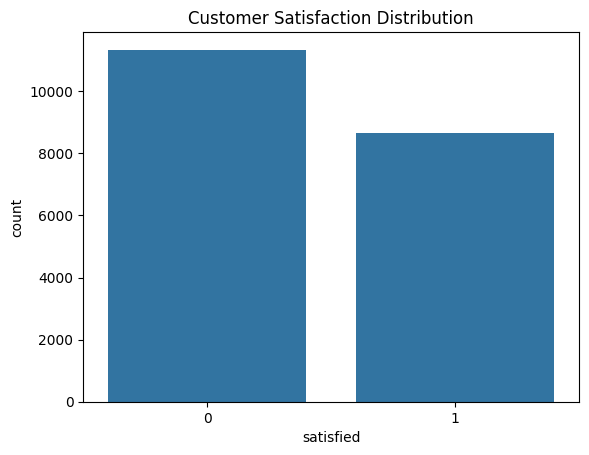

In [ ]:
sns.countplot(x="satisfied", data=df)
plt.title("Customer Satisfaction Distribution")
plt.show();

In [ ]:
df['satisfied'].value_counts()

,count
satisfied,
0,11339
1,8661


- The satisfaction distribution shows a moderate class imbalance between satisfied and not satisfied customers.

- There are 11,339 unsatisfied customers (0) and 8,661 satisfied customers (1). This means that the dataset contains more negative feedback than positive, but the difference is not extreme.

- The target variable is relatively balanced, so it is suitable for classification modeling without requiring strong rebalancing techniques.

### Feature Insights

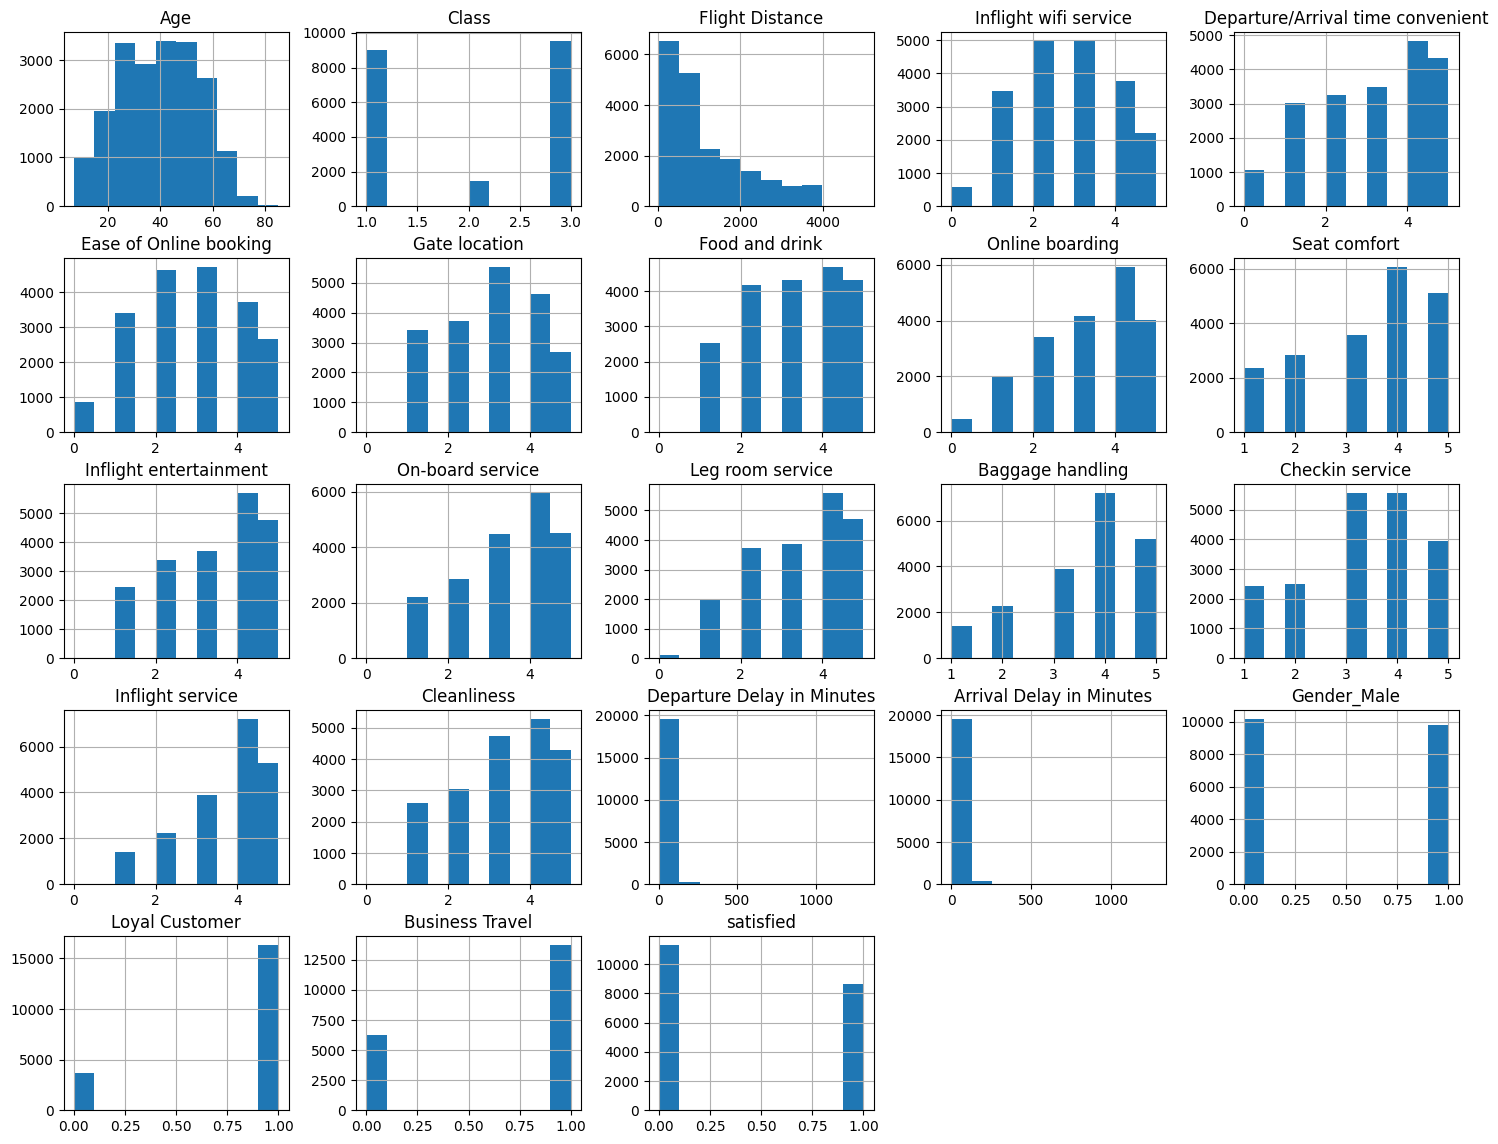

In [ ]:
df.hist(figsize=(18,14))
plt.show();

- The histograms provide an overall view of how each feature is distributed and highlight clear patterns in passenger behavior, service perception, and operational conditions.

- Passenger demographics show a mostly normal age distribution, with the majority of customers concentrated between 25 and 60 years old. Flight class is unevenly distributed, with strong peaks at the lower and upper encoded values, suggesting most passengers belong to Economy or Business class, while the middle category is less common. Flight distance is heavily right-skewed, meaning most flights are short to medium distance, with relatively few long-haul trips.

- Binary behavioral features indicate clear trends. Most passengers are loyal customers, and a large portion of trips are business-related rather than personal travel. Gender distribution appears relatively balanced.

- Service rating features (mostly on a 1–5 scale) generally show a positive skew toward higher ratings. Operational services such as inflight entertainment, on-board service, baggage handling, and inflight service are mostly rated 4 or 5, indicating strong perceived performance. Food and drink, cleanliness, and seat comfort show slightly more variation but still lean toward positive ratings.

- In contrast, digital and pre-flight services such as inflight WiFi service and ease of online booking show more spread and weaker concentration at high ratings, suggesting these are weaker areas in the customer experience.

- Delay-related features (departure and arrival delays) are highly right-skewed, with most values close to zero and a small number of extreme outliers, indicating that while delays are generally rare, they can occasionally be very severe.

- The target variable remains relatively balanced, with slightly more dissatisfied customers than satisfied ones, reinforcing that despite generally positive service ratings, overall satisfaction is not overwhelmingly high.

- Overall, the distributions suggest strong operational service performance, weaker digital experience, minimal but impactful delay outliers, and a satisfaction outcome that is influenced by a mix of factors rather than any single dominant feature.

### Correlation Heatmap

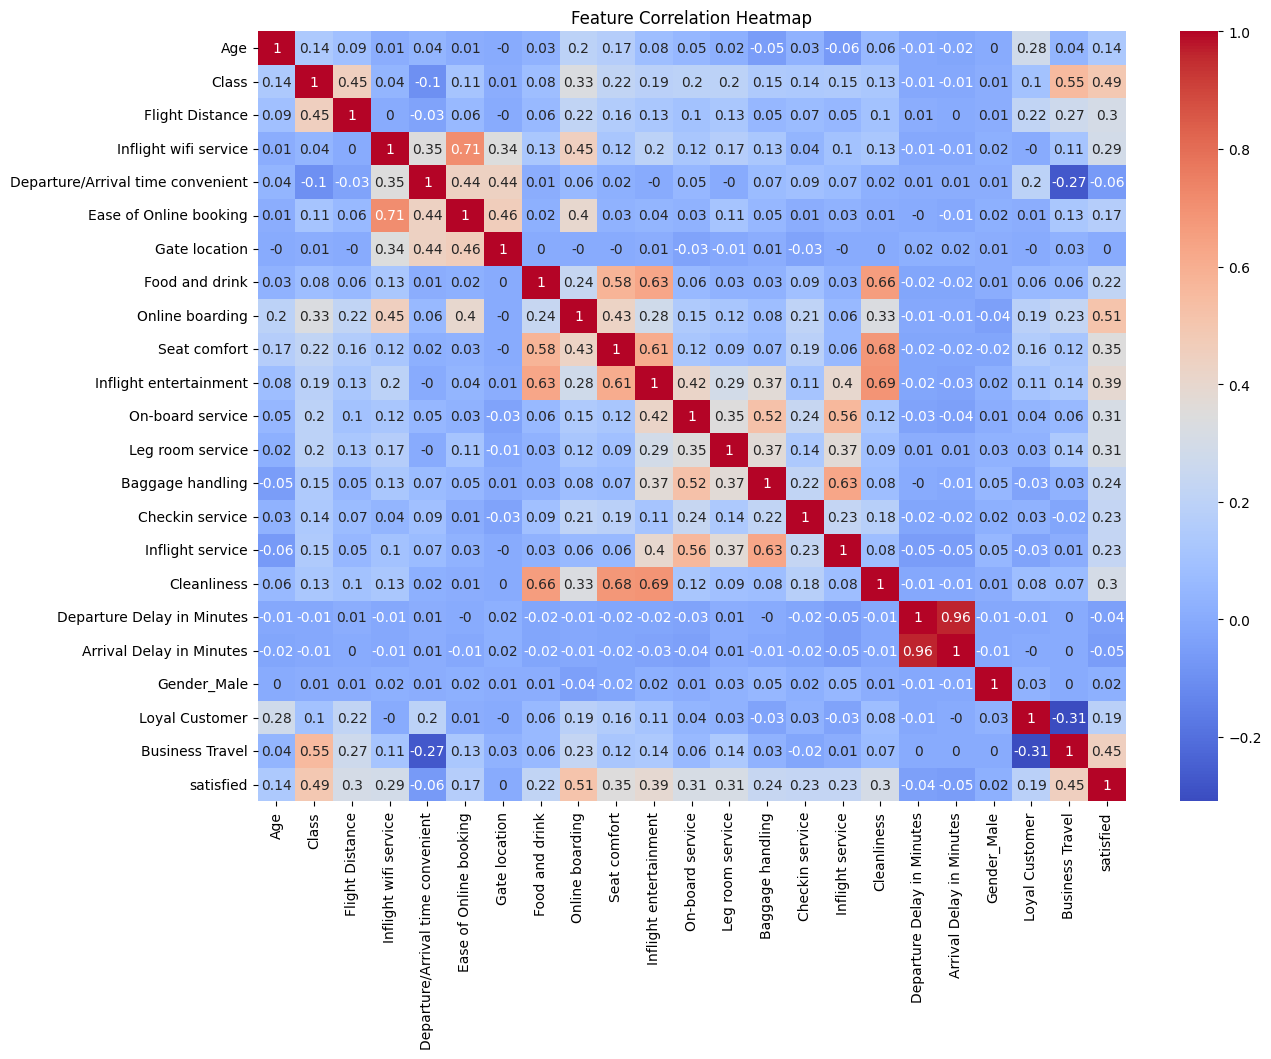

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr().round(2), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show();

- Customer satisfaction shows its strongest relationships with a few key features. Online boarding has the highest positive correlation (around 0.51), making it the most influential single factor in satisfaction. Class (0.49) and Business Travel (0.45) also show strong positive relationships, indicating that premium or business-oriented passengers are more likely to be satisfied. Other moderate contributors include inflight entertainment (0.39), seat comfort (0.35), and on-board service (0.31), all reflecting the importance of in-flight experience quality.

- Several strong feature clusters indicate multicollinearity. The most extreme is between departure delay and arrival delay, which are almost perfectly correlated (~0.96), showing they represent essentially the same phenomenon. A second cluster appears in digital services, where inflight WiFi service, ease of online booking, and online boarding are moderately to strongly correlated with each other, suggesting they represent a shared “digital experience” factor. Another cluster exists among comfort-related features such as cleanliness, seat comfort, inflight entertainment, and food and drink, which all show strong positive relationships, indicating passengers tend to evaluate cabin experience holistically rather than independently.

- Operational service features such as inflight service, baggage handling, and on-board service are also moderately correlated, forming a consistent “service quality” group.

- Some features show weak or negligible correlation with most variables. Gender_Male has virtually no meaningful linear relationship with satisfaction or other features, indicating gender does not influence satisfaction in this dataset. Age also shows weak correlations overall, with only minor relationships to loyalty and online boarding. Gate location is similarly weakly related to satisfaction, suggesting it has little impact on customer experience.

- A few mild negative correlations appear, particularly between loyal customer and business travel, which may reflect how customer types are distributed rather than a true behavioral contradiction. There is also a slight negative relationship between business travel and time convenience, suggesting business travelers may be more sensitive to scheduling constraints.

- Overall, the heatmap highlights that satisfaction is primarily driven by digital experience, travel class, and in-flight service quality, while delays form a tightly linked operational factor and demographic variables contribute relatively little direct predictive power.

## Data Preprocessing

### Drop Target for Clustering

In [ ]:
df_cluster = df.drop(columns=["satisfied"])

### Scale Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

- For clustering, the `satisfied` target column was removed to focus only on the features describing passenger behavior and flight experience.

- All remaining features were standardized using `StandardScaler` to ensure they have a mean of 0 and a standard deviation of 1. This step prevents features with larger numeric ranges, like Flight Distance or Delay minutes, from dominating the clustering process.

## Finding Optimal Clusters
### Elbow Method

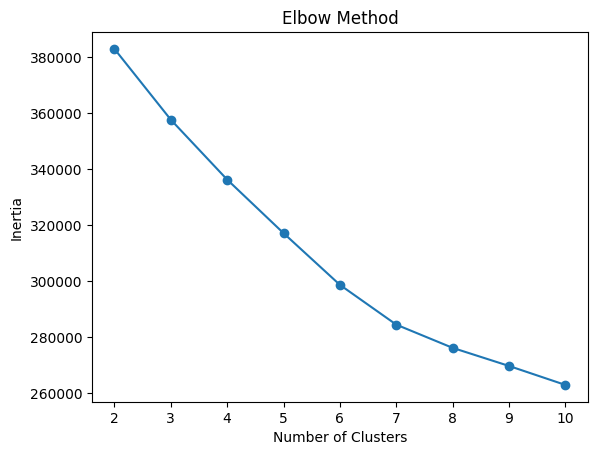

In [ ]:
inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show();

### Silhouette Score

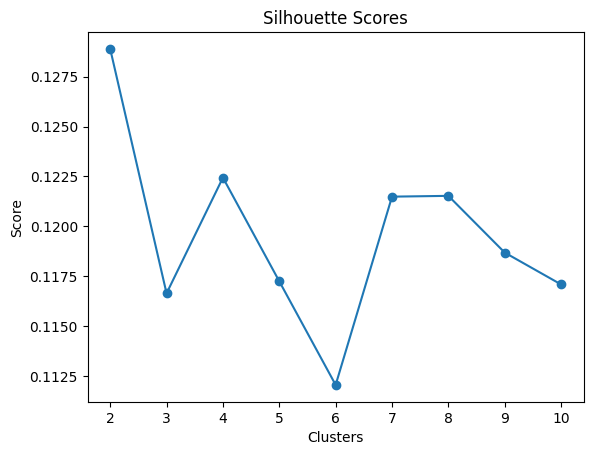

In [ ]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Clusters")
plt.ylabel("Score")
plt.show();

- To determine the optimal number of clusters for KMeans, two methods were used: the Elbow method and Silhouette scores.

- The Elbow method plots inertia versus the number of clusters, showing where adding more clusters yields diminishing returns in reducing within-cluster variance.

- Silhouette scores measure how well each point fits within its cluster, with higher scores indicating better-defined clusters.

- Both analyses indicated that **2 clusters** is optimal, as it produced the highest silhouette score. This suggests the data naturally separates into two distinct groups.

## Final KMeans Model

In [ ]:
optimal_k = 2

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters
df.head()

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Loyal Customer,Business Travel,satisfied,cluster
0,26,3,2062,2,3,3,3,2,2,2,2,3,3,3,3,3,2,0,0,0,1,1,0,0
1,52,3,680,5,5,5,5,3,4,4,4,4,4,4,4,4,4,18,2,0,1,1,1,1
2,28,1,188,3,5,3,4,3,3,3,3,3,3,4,4,5,3,0,0,1,1,0,0,0
3,54,3,453,3,5,5,5,3,4,4,3,3,3,3,4,3,1,91,80,0,1,1,0,0
4,40,1,775,4,3,3,3,4,4,4,4,1,1,3,3,3,4,0,0,1,1,1,0,0


## Cluster Analysis
### Cluster Sizes

In [ ]:
df["cluster"].value_counts()

,count
cluster,
1,10364
0,9636


### Cluster Means

In [ ]:
cluster_summary = df.groupby("cluster").mean()
cluster_summary

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Loyal Customer,Business Travel,satisfied
cluster,,,,,,,,,,,,,,,,,,,,,,,
0,37.323786,1.664799,938.281445,2.310710,2.949253,2.481009,2.925280,2.488066,2.594645,2.608863,2.337796,2.809568,2.878580,3.154213,2.948941,3.155666,2.463885,15.754774,16.346928,0.476961,0.757887,0.57856,0.158987
1,41.479448,2.365303,1421.235044,3.115882,3.155442,3.002219,3.014184,3.865978,3.869548,4.211019,4.289367,3.920687,3.789946,4.060112,3.631899,4.081725,4.043902,12.982825,13.165380,0.503377,0.873601,0.78956,0.687862


- The KMeans clustering divided the dataset into **2 clusters**, with a fairly balanced distribution: cluster 1 contains 10,364 passengers, while cluster 0 has 9,636.

- Examining the cluster averages reveals clear differences between the two groups:

  - Cluster 0 tends to represent younger passengers (average age 37), mostly in lower travel classes (1.66), with shorter flights (938 miles). Their service ratings are generally lower across digital and inflight experiences. Only a small fraction are satisfied (16%), indicating this group captures less happy passengers. Loyalty and business travel rates are moderate (~0.76 and ~0.58).

  - Cluster 1 represents older passengers (average age 41), traveling more often in higher classes (2.37) on longer flights (1,421 miles). They give higher ratings across most service features, particularly online boarding, seat comfort, and inflight entertainment. Satisfaction is much higher in this cluster (69%), with a higher proportion of loyal customers (0.87) and business travelers (~0.79).

- Overall, clustering highlights two distinct passenger segments: one younger, lower-class, lower-satisfaction group, and one older, premium-class, high-satisfaction group. This segmentation can inform targeted improvements and personalized strategies.

### Satisfaction by Cluster

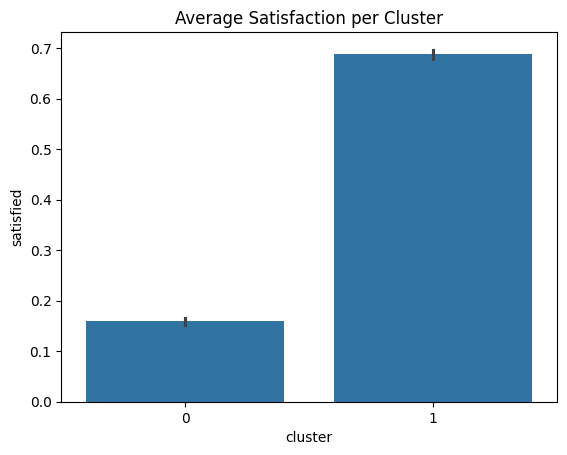

In [ ]:
sns.barplot(x="cluster", y="satisfied", data=df)
plt.title("Average Satisfaction per Cluster")
plt.show();

- The bar plot shows the **average satisfaction per cluster**, confirming the cluster characteristics observed earlier.

- Cluster 1 has a high average satisfaction (0.7), indicating most passengers in this group are satisfied. Cluster 0 has a very low average satisfaction (~0.16–0.2), showing that this group contains mostly unsatisfied passengers.

This visualization clearly demonstrates that the clustering successfully separated passengers into low- and high-satisfaction segments.

### Feature Comparison

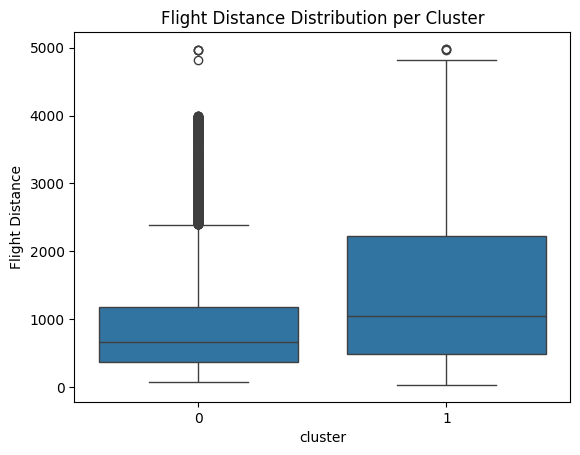

In [ ]:
sns.boxplot(x="cluster", y="Flight Distance", data=df)
plt.title("Flight Distance Distribution per Cluster")
plt.show();

- The boxplot shows the **distribution of flight distances per cluster**, highlighting clear differences between the two groups.

- Cluster 0 represents mostly short-haul passengers, with a median distance around 650–700 units and many extreme outliers above 2,400 units. The distribution is right-skewed, showing most flights are short, but a few long-distance flights exist as anomalies.

- Cluster 1 covers a broader range of distances, with a median around 1,000–1,100 units and a taller interquartile range, capturing short, medium, and long-haul flights. Outliers are rare, as long distances are normal in this cluster.

- Overall, Cluster 0 can be described as **short-range/regional travelers**, while Cluster 1 represents **diverse/long-range travelers**, aligning with the satisfaction patterns observed earlier.

### Clustering Conclusions

#### Cluster 0 — Short-Range / Regional Travelers

* Passengers in this cluster are generally younger and mostly fly shorter distances.
* Travel class tends to be lower, and service ratings are moderate to low.
* Satisfaction is very low (~16%), with a mix of personal and business travelers.
* This cluster represents short-haul or regional passengers who are less satisfied with their overall experience.

#### Cluster 1 — Long-Range / Premium Travelers

* Passengers here are slightly older and fly longer distances on average.
* Travel class is higher, and service ratings across digital and inflight experiences are consistently higher.
* Satisfaction is high (~70%), and most passengers are loyal or business travelers.
* This cluster represents medium-to-long-haul travelers who enjoy premium services and report higher satisfaction.

Overall, the clustering reveals **two distinct passenger segments**: one focused on short regional trips with low satisfaction, and another encompassing longer, higher-class trips with high satisfaction. These segments can guide targeted service improvements and marketing strategies.

## Prepare Data for Prediction Model
### Split Features and Target

In [ ]:
X = df.drop(columns=["satisfied", "cluster"])
y = df["satisfied"]

### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scale Data

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### PCA Transformation

In [ ]:
pca = PCA(n_components=0.95)  # keep 95% variance

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 22
Reduced features: 17


- Before building a deep learning model, **PCA (Principal Component Analysis)** was applied to reduce feature dimensionality while retaining most of the information.

- The dataset was split into training (80%) and testing (20%) sets. Features were standardized to have mean 0 and variance 1.

- PCA was then applied to keep **95% of the variance**, reducing the number of features from **22 original features** to **17 principal components**.

- This dimensionality reduction simplifies the model, removes redundancy, and can improve training efficiency without significant loss of information.

## Deep Learning Models
### Model 1 — Baseline Model

In [ ]:
model1 = Sequential()

model1.add(Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history1 = model1.fit(
    X_train_pca, y_train,
    validation_split=0.2,
    epochs=20,
    verbose=1
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8770 - loss: 0.3241 - val_accuracy: 0.8994 - val_loss: 0.2655
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9126 - loss: 0.2212 - val_accuracy: 0.9100 - val_loss: 0.2260
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9195 - loss: 0.1959 - val_accuracy: 0.9203 - val_loss: 0.2069
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9241 - loss: 0.1840 - val_accuracy: 0.9219 - val_loss: 0.1966
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9263 - loss: 0.1757 - val_accuracy: 0.9184 - val_loss: 0.1981
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9287 - loss: 0.1693 - val_accuracy: 0.9250 - val_loss: 0.1838
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9320 - loss: 0.1644 - val_accuracy: 0.9247 - val_loss: 0.1875
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9322 - loss: 0.1602 - val_accuracy: 0.

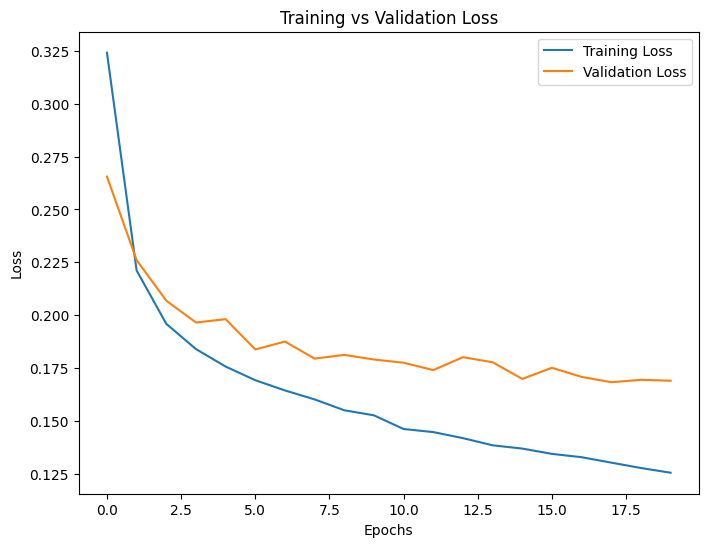

In [ ]:
plot_history(history1);

In [ ]:
results1 = model1.evaluate(X_test_pca, y_test, return_dict=True)

results1

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9285 - loss: 0.1818


{'accuracy': 0.9284999966621399, 'loss': 0.18177147209644318}

- A baseline neural network model was built using the PCA-transformed features as input.

- The architecture consists of two hidden layers with 64 and 32 neurons respectively, both using ReLU activation, followed by a sigmoid output layer for binary classification.

- The model was compiled using the Adam optimizer and binary cross-entropy loss, and trained for 20 epochs with a validation split of 20%.

- During training, the model showed steady improvement, reaching a validation accuracy of around 93% and a training accuracy close to 95%, indicating good learning behavior with no severe overfitting.

- On the test set, the model achieved an accuracy of approximately 92.8% with a low loss value, providing a strong baseline performance for the customer satisfaction prediction task.

### Model 2 — Deeper Network

In [ ]:
model2 = Sequential()

model2.add(Dense(128, activation='relu', input_shape=(X_train_pca.shape[1],)))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history2 = model2.fit(
    X_train_pca, y_train,
    validation_split=0.2,
    epochs=20,
    verbose=1
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8869 - loss: 0.2852 - val_accuracy: 0.9019 - val_loss: 0.2372
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9178 - loss: 0.1977 - val_accuracy: 0.9156 - val_loss: 0.2106
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9250 - loss: 0.1780 - val_accuracy: 0.9075 - val_loss: 0.2271
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9304 - loss: 0.1629 - val_accuracy: 0.9222 - val_loss: 0.1888
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9368 - loss: 0.1501 - val_accuracy: 0.9256 - val_loss: 0.1786
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9405 - loss: 0.1410 - val_accuracy: 0.9253 - val_loss: 0.1815
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9450 - loss: 0.1327 - val_accuracy: 0.9272 - val_loss: 0.1794
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9468 - loss: 0.1272 - val_accuracy: 0.

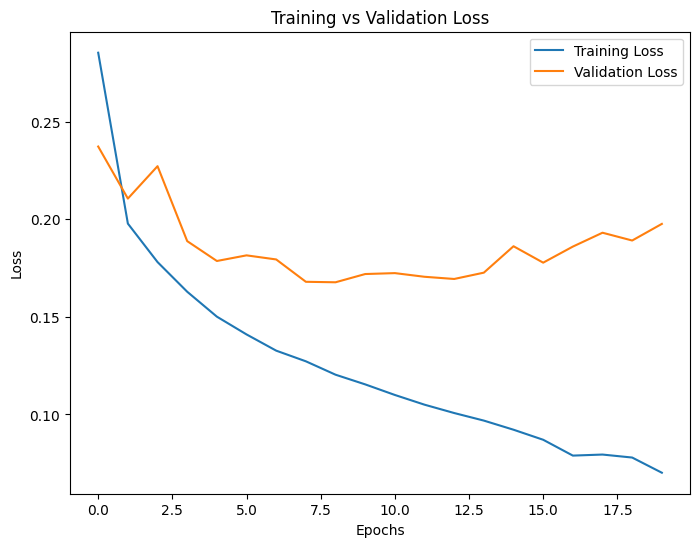

In [ ]:
plot_history(history2);

In [ ]:
results2 = model2.evaluate(X_test_pca, y_test, return_dict=True)

results2

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9345 - loss: 0.2174


{'accuracy': 0.934499979019165, 'loss': 0.21737897396087646}

- A deeper neural network was constructed to improve the baseline performance.

- The model architecture includes three hidden layers with 128, 64, and 32 neurons respectively, all using ReLU activation, followed by a sigmoid output layer for binary classification. This increases the model capacity compared to the baseline.

- The model was compiled with the Adam optimizer and binary cross-entropy loss, and trained for 20 epochs with a validation split of 20%.

- During training, the deeper model achieved higher training accuracy, reaching nearly 97%, while the validation accuracy peaked around 93–94%. The training loss decreased steadily, indicating effective learning without severe overfitting.

- On the test set, the model achieved an accuracy of approximately 93.5% with a slightly higher loss compared to training, demonstrating improved predictive performance over the baseline model while maintaining generalization.

### Model 3 — Regularized Model

In [ ]:
model3 = Sequential()

model3.add(Dense(128, activation='relu', input_shape=(X_train_pca.shape[1], ), kernel_regularizer=l2(0.01)))
model3.add(Dropout(0.3))

model3.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model3.add(Dropout(0.3))

model3.add(Dense(32, activation='relu'))

model3.add(Dense(1, activation="sigmoid"))

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
early_stop = EarlyStopping(patience=5)

In [ ]:
history3 = model3.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8566 - loss: 0.7053 - val_accuracy: 0.8903 - val_loss: 0.3814
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9009 - loss: 0.3272 - val_accuracy: 0.9094 - val_loss: 0.2879
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9067 - loss: 0.2825 - val_accuracy: 0.9016 - val_loss: 0.2880
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9091 - loss: 0.2705 - val_accuracy: 0.9044 - val_loss: 0.2766
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9102 - loss: 0.2612 - val_accuracy: 0.9172 - val_loss: 0.2504
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9145 - loss: 0.2505 - val_accuracy: 0.9191 - val_loss: 0.2406
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9143 - loss: 0.2507 - val_accuracy: 0.9219 - val_loss: 0.2368
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9177 - loss: 0.2416 - val_accuracy: 0

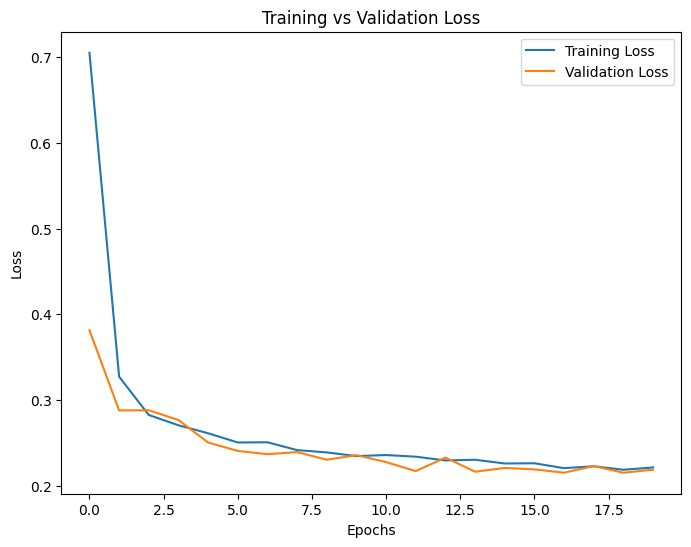

In [ ]:
plot_history(history3);

In [ ]:
results3 = model3.evaluate(X_test_pca, y_test, return_dict=True)

results3

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9327 - loss: 0.2125


{'accuracy': 0.9327499866485596, 'loss': 0.21254032850265503}

- A regularized neural network was built to reduce overfitting and improve generalization.

- The model uses two Dense layers (128 and 64 neurons) with L2 regularization and Dropout (0.3) applied after each layer, followed by a 32-neuron hidden layer and a sigmoid output layer for binary classification.

- Early stopping was added with a patience of 5 epochs to stop training when validation performance stops improving.

- During training, the model showed more stable learning with validation accuracy reaching around 92–93%, while training accuracy remained controlled compared to previous models, indicating reduced overfitting.

- On the test set, the model achieved an accuracy of approximately 93.3% with a similar loss to previous models. While accuracy is close to the deeper model, this version is more robust and better regularized, making it a more reliable final model for generalization.

## Model Evaluation
### Evaluate All Models

In [ ]:
print("Model 1:", model1.evaluate(X_test_pca, y_test))
print("Model 2:", model2.evaluate(X_test_pca, y_test))
print("Model 3:", model3.evaluate(X_test_pca, y_test))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9285 - loss: 0.1818
Model 1: [0.18177147209644318, 0.9284999966621399]
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9345 - loss: 0.2174
Model 2: [0.21737897396087646, 0.934499979019165]
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9327 - loss: 0.2125
Model 3: [0.21254032850265503, 0.9327499866485596]


- The three models were evaluated on the test set to compare their final performance.

- Model 1 (baseline) achieved an accuracy of approximately 92.85% with the lowest loss, serving as a strong starting point.

- Model 2 (deeper network) performed the best overall in terms of accuracy, reaching about 93.45%, making it the most accurate model among the three.

- Model 3 (regularized model) achieved a slightly lower accuracy of around 93.27%, but with improved generalization due to dropout and L2 regularization.

- Overall, Model 2 provides the highest predictive performance, while Model 3 offers better robustness against overfitting.

### Predictions

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


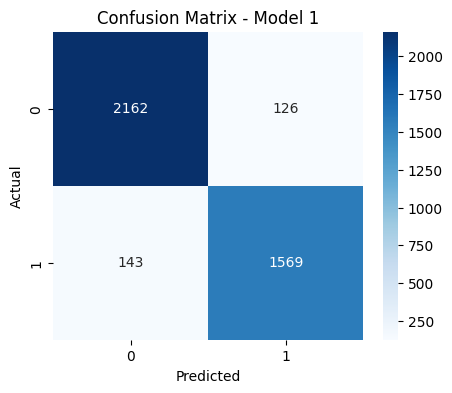

In [ ]:
y_pred_prob = model3.predict(X_test_pca)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model 3")
plt.show();

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2288
           1       0.93      0.92      0.92      1712

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



- The final evaluation of Model 3 shows strong classification performance:

- The confusion matrix indicates that the model correctly predicts most satisfied and unsatisfied customers, with slightly more misclassifications in the satisfied class.

- The classification report highlights:

  * **Precision:** 0.94 for unsatisfied, 0.93 for satisfied
  * **Recall:** 0.94 for unsatisfied, 0.92 for satisfied
  * **F1-score:** 0.94 for unsatisfied, 0.92 for satisfied
  * **Overall accuracy:** 0.93

- This confirms that Model 3 is balanced, accurate, and reliable for predicting customer satisfaction.

## Business Interpretation

**What the model achieves:**

The model predicts whether an airline customer is satisfied or not based on travel experience, service ratings, and behavioral features. It achieves strong classification performance with around 93% accuracy.

**Business impact:**

The model can help airlines identify factors influencing customer satisfaction and dissatisfaction. It supports improving service quality by highlighting weak areas such as digital experience, comfort, or delays. It can also be used to segment customers and prioritize improvements that have the highest impact on satisfaction.

**Limitations:**

The use of PCA improves performance but reduces interpretability of individual features. The model also depends on a fixed classification threshold (0.5), which may affect precision and recall trade-offs in real business decisions.

## Final Conclusion

**Best Cluster Insights Summary:**

* **Cluster 1 — Engaged & Long-Haul Travelers** is the most satisfied group (~70% satisfaction) and typically takes longer flights with higher expectations for in-flight services.
* **Cluster 0 — Short-Haul / Regional Travelers** shows low satisfaction (~16%) and may experience frustration with specific service aspects.
* These clusters reveal meaningful differences in travel distance, service needs, and overall satisfaction patterns, enabling targeted improvements.

**Best Model Performance Summary:**

* **Model 3** (Deep Neural Network with regularization and dropout) achieved strong predictive performance:

  * Accuracy: **93.3%**
  * Balanced precision and recall for both satisfied and dissatisfied customers
  * Confusion matrix shows effective classification of both groups, supporting actionable insights.

**Final Recommendation to Airline:**

* Focus on **enhancing the experience of Cluster 0 travelers** by improving inflight services, comfort, and online booking ease.
* Use **Model 3** to monitor satisfaction in real-time, predict dissatisfied customers, and proactively address service gaps.
* Leverage clustering insights to **personalize services and marketing strategies**, ensuring higher satisfaction and customer loyalty across all traveler segments.